In [113]:
import os
import sys
import pandas as pd 
import numpy as np
import glob
import time
#import gget
import scipy
from scipy.sparse import csr_matrix
import anndata as an
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import ListedColormap
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

source_path = os.path.abspath("../utilities/")
sys.path.append(source_path)
import matrix as matrix
source_path = os.path.abspath("../utilities/calculations/")
sys.path.append(source_path)
import centrality as central

In [114]:
CN     = pd.read_csv("/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/pop_mESC_1000000_node_core.csv", index_col='bin_name')
CE     = pd.read_csv("/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/pop_mESC_1000000_edge_core-temp.csv", index_col='read_name')
H_core = sp.load_npz("/scratch/indikar_root/indikar1/jduhamel/pore_c/H_core_temp.npz")   # rows = CN, cols = CE

print(f"CN: {len(CN)} core nodes")
print(f"CE: {len(CE)} core edges")
print(f"H_core: {H_core.shape}")
print(f"\nCN columns:  {CN.columns.tolist()}")
print(f"CE columns:  {CE.columns.tolist()}")

CN.head()

CN: 195 core nodes
CE: 83144 core edges
H_core: (195, 83144)

CN columns:  ['bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII', 'degree_outlier', 'global_hge_logexp_unweighted', 'node_curvature', 'normalized_node_curvature', 'abs_normalized_node_curvature']
CE columns:  ['read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes', 'edge_curvature', 'normalized_edge_curvature', 'abs_normalized_edge_curvature', 'global_hge_logexp_unweighted', 'edge_class']


,bin_index,bin_start,bin_end,bin,chrom,chrom_bin,degree,genes,n_genes,ATACSeq_1,...,RNA_3,RNA_4,RNA_5,RNA_6,PolII,degree_outlier,global_hge_logexp_unweighted,node_curvature,normalized_node_curvature,abs_normalized_node_curvature
bin_name,,,,,,,,,,,,,,,,,,,,,
chr3:34,16,34000000,35000000,412,3,34,4126,Gm9791;Sox2ot;Dnajc19;Gm34599;Gm21388;Gm29135;...,23,0.654700,...,0.187619,0.425621,1.903160,0.135107,0.848217,False,0.000437,-12680004,-3553.812780,3553.812780
chr6:93,21,93000000,94000000,940,6,93,4187,Gm5313;Gm22312;Gm44220;9530026P05Rik;Magi1;Gm4...,10,0.706136,...,0.140705,0.090659,0.162810,0.099323,0.487627,False,0.000437,-13225816,-3632.468003,3632.468003
chr3:32,42,32000000,33000000,410,3,32,4048,Kcnmb3;Mrpl47;Gm37834;Usp13;Zfp639;Gm37770;Kcn...,16,0.672969,...,0.194078,0.193396,0.705671,0.154875,1.295672,False,0.000437,-12603137,-3548.180462,3548.180462
chr18:3,46,3000000,4000000,2322,18,3,4248,Gm50073;Gm50075;Cul2;Gm50088;G430049J08Rik;Cre...,20,0.466249,...,0.154656,0.151137,0.219633,0.113674,0.416700,False,0.000440,-13224779,-3634.179445,3634.179445
chr12:113,55,113000000,114000000,1764,12,113,4244,Ighd5-3;Ighd5-1;Ighv2-5;Ighv5-12;Ighj4;Ighv5-4...,94,0.668532,...,0.187602,0.182494,0.592320,0.158550,0.721855,False,0.000439,-13737222,-3702.755256,3702.755256


In [115]:
%%time 
# 1MB resolution
resolution = 1000000

fpath = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/population_mESC_{resolution}_features.h5ad"

adata = sc.read_h5ad(fpath)

sc.logging.print_memory_usage()

adata.obs

Memory usage: current 10.54 GB, difference +2.24 GB
CPU times: user 12.8 s, sys: 2.98 s, total: 15.8 s
Wall time: 18.3 s


,bin_index,bin_start,bin_end,bin,chrom,chrom_bin,degree,genes,n_genes,ATACSeq_1,...,CTCF,H3K27ac,H3K27me3,RNA_1,RNA_2,RNA_3,RNA_4,RNA_5,RNA_6,PolII
bin_name,,,,,,,,,,,,,,,,,,,,,
chr9:121,0,121000000,122000000,1394,9,121,3532,Gm47092;Higd1a;Gm47108;Gask1a;Lyzl4os;Gm47112;...,41,0.826484,...,1.149226,1.349552,0.866066,0.295370,0.387013,0.162437,0.225783,0.573875,0.122417,1.016765
chr19:26,1,26000000,27000000,2436,19,26,3346,Gm50378;Smarca2;Gm50376;Gm48775;Gm815;1700048O...,11,0.497386,...,0.547185,0.336787,0.839273,0.133999,0.148066,0.132291,0.094680,0.141617,0.084908,0.417178
chr4:127,2,127000000,128000000,665,4,127,3768,Gjb3;Gm22221;Gm12943;Zmym6;Tmem35b;Gjb5;Gm1294...,16,0.754788,...,1.027046,1.577616,0.839461,0.521087,0.998980,0.293742,0.247401,0.906364,0.256514,0.750054
chr8:21,3,21000000,22000000,1163,8,21,12931,Defa5;Gm23142;Gm21092;Gm15304;Gm56829;Gm6689;D...,47,0.226766,...,0.218299,0.135160,0.243308,0.130106,0.336687,0.121854,0.090845,0.063376,0.155842,0.187819
chr10:57,4,57000000,58000000,1455,10,57,3285,Serinc1;Smpdl3a;Rpl48-ps1;Gm19256;Gm48055;Fabp...,14,0.472903,...,0.383735,0.229388,0.600799,0.238078,0.560188,0.233549,0.215554,0.490113,0.182086,0.176728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr16:7,2574,7000000,8000000,2131,16,7,3437,Gm49535;Rbfox1;Gm49534;Gm49533,4,0.475243,...,0.438346,0.469556,0.659370,0.148148,0.068007,0.179972,0.094459,0.056656,0.136702,0.305652
chr1:159,2575,159000000,160000000,159,1,159,3435,Gm24719;Tnn;Tnr;Gm37757;Gm37731;Cop1;Gm38039;G...,15,0.752434,...,0.549626,0.373921,0.752304,0.179105,0.177992,0.340071,0.134395,0.253093,0.089073,0.572138
chr9:116,2576,116000000,117000000,1389,9,116,3541,Rbms3;Gm31410;Gm48038;D730003K21Rik;Tgfbr2;Gm4668,6,0.732873,...,0.708854,0.643508,0.690798,0.118125,0.252528,0.170411,0.084363,0.289917,0.141768,0.441737


In [116]:
obs_idx = np.arange(adata.n_obs)
adata.obs.iloc[obs_idx[5]].name

'chr12:8'

In [117]:
def find_outliers_iqr(df_column):
  """
  Identifies outliers in a pandas DataFrame column using the IQR method.

  Args:
    df_column: A pandas Series representing the column to analyze.

  Returns:
    A boolean mask with True for outliers and False otherwise.
  """
  Q1 = df_column.quantile(0.15)
  Q3 = df_column.quantile(0.85)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  return (df_column < lower_bound) | (df_column > upper_bound)

adata.obs['degree_outlier'] = find_outliers_iqr(adata.obs['degree'])

adata.obs[adata.obs['degree_outlier']][['chrom_bin', 'degree', 'degree_outlier']].head()

,chrom_bin,degree,degree_outlier
bin_name,,,
chr8:21,21,12931,True
chrX:139,139,1609,True
chrX:122,122,1726,True
chrX:123,123,610,True
chr8:20,20,15415,True


In [118]:
# remove outliers
remove_bins = adata.obs[adata.obs['degree_outlier']].index.to_list()
print(f"Removing {len(remove_bins)} outlier loci: ")
print(remove_bins)

adata = adata[~adata.obs_names.isin(remove_bins), :].copy()
#bdata = bdata[~bdata.obs_names.isin(remove_bins), :].copy()

print('done!')

Removing 148 outlier loci: 
['chr8:21', 'chrX:139', 'chrX:122', 'chrX:123', 'chr8:20', 'chrX:124', 'chr1:85', 'chrX:110', 'chrX:14', 'chrX:63', 'chrX:169', 'chr14:18', 'chrX:9', 'chrX:154', 'chr9:124', 'chrX:15', 'chrX:82', 'chr9:3', 'chrX:6', 'chrX:61', 'chrX:88', 'chrX:109', 'chrX:29', 'chrX:27', 'chrX:137', 'chr14:19', 'chrX:84', 'chrX:120', 'chrX:97', 'chrX:24', 'chrX:118', 'chr8:19', 'chrX:156', 'chr1:24', 'chrX:108', 'chrX:135', 'chrX:68', 'chrX:42', 'chrX:111', 'chr14:15', 'chrX:130', 'chr14:16', 'chrX:80', 'chrX:64', 'chrX:134', 'chrX:127', 'chrX:155', 'chr8:70', 'chrX:18', 'chrX:141', 'chrX:45', 'chrX:121', 'chr4:112', 'chr11:3', 'chr12:3', 'chrX:167', 'chrX:95', 'chrX:65', 'chr14:3', 'chrX:77', 'chr2:177', 'chrX:44', 'chrX:60', 'chrX:86', 'chrX:46', 'chr2:98', 'chrX:19', 'chrX:23', 'chrX:79', 'chrX:119', 'chr14:17', 'chrX:107', 'chrX:89', 'chr4:146', 'chr4:147', 'chrX:132', 'chrX:113', 'chrX:94', 'chrX:157', 'chrX:93', 'chr7:22', 'chr7:21', 'chrX:128', 'chr9:35', 'chrX:96', '

In [119]:
fpath = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/pop_mESC_1000000_hge_logexp_nodes.csv"
bpath = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/pop_mESC_1000000_poset_curvature_nodes.csv"
df_1 = pd.read_csv(fpath)
df_2 = pd.read_csv(bpath)

print(f"{df_1.shape=}")
print(df_1.columns)
print(f"{df_2.shape=}")
print(df_2.columns)

df_1.shape=(2335, 5)
Index(['bin_name', 'chrom', 'bin_start', 'bin_end',
       'global_hge_logexp_unweighted'],
      dtype='object')
df_2.shape=(2335, 10)
Index(['node_id', 'bin_name', 'chrom_bin', 'chrom', 'bin_start', 'bin_end',
       'degree', 'scalar_curvature', 'normalized_scalar_curvature',
       'abs_normalized_edge_curvature'],
      dtype='object')


In [120]:
#columns_to_drop = [x for x in df.columns if x in adata.obs.columns]
columns_to_drop = ["chrom", "bin_start", "bin_end"]
df_1 = df_1.drop(columns=columns_to_drop)
print(f"{df_1.shape=}")
df_1.head()

df_1.shape=(2335, 2)


,bin_name,global_hge_logexp_unweighted
0,chr9:121,0.000428
1,chr19:26,0.000421
2,chr4:127,0.000433
3,chr10:57,0.000425
4,chr12:8,0.000426


In [121]:
columns_to_drop_2 = ["chrom", "bin_start", "bin_end", "node_id", "chrom_bin", "degree"]
df_2 = df_2.drop(columns=columns_to_drop_2)
print(f"{df_2.shape=}")
df_2.head()

df_2.shape=(2335, 4)


,bin_name,scalar_curvature,normalized_scalar_curvature,abs_normalized_edge_curvature
0,chr9:121,-9300499,-3045.350033,3045.350033
1,chr19:26,-8314541,-2880.991337,2880.991337
2,chr4:127,-10683981,-3262.284275,3262.284275
3,chr10:57,-7936616,-2815.401206,2815.401206
4,chr12:8,-9343189,-3056.326137,3056.326137


In [122]:
adata.obs = pd.merge(
    adata.obs, df_1.set_index('bin_name'),
    how='left',
    left_index=True,
    right_index=True,
)

adata.obs = pd.merge(
    adata.obs, df_2.set_index('bin_name'),
    how='left',
    left_index=True,
    right_index=True,
)

adata.obs

,bin_index,bin_start,bin_end,bin,chrom,chrom_bin,degree,genes,n_genes,ATACSeq_1,...,RNA_3,RNA_4,RNA_5,RNA_6,PolII,degree_outlier,global_hge_logexp_unweighted,scalar_curvature,normalized_scalar_curvature,abs_normalized_edge_curvature
bin_name,,,,,,,,,,,,,,,,,,,,,
chr9:121,0,121000000,122000000,1394,9,121,3532,Gm47092;Higd1a;Gm47108;Gask1a;Lyzl4os;Gm47112;...,41,0.826484,...,0.162437,0.225783,0.573875,0.122417,1.016765,False,0.000428,-9300499.0,-3045.350033,3045.350033
chr19:26,1,26000000,27000000,2436,19,26,3346,Gm50378;Smarca2;Gm50376;Gm48775;Gm815;1700048O...,11,0.497386,...,0.132291,0.094680,0.141617,0.084908,0.417178,False,0.000421,-8314541.0,-2880.991337,2880.991337
chr4:127,2,127000000,128000000,665,4,127,3768,Gjb3;Gm22221;Gm12943;Zmym6;Tmem35b;Gjb5;Gm1294...,16,0.754788,...,0.293742,0.247401,0.906364,0.256514,0.750054,False,0.000433,-10683981.0,-3262.284275,3262.284275
chr10:57,4,57000000,58000000,1455,10,57,3285,Serinc1;Smpdl3a;Rpl48-ps1;Gm19256;Gm48055;Fabp...,14,0.472903,...,0.233549,0.215554,0.490113,0.182086,0.176728,False,0.000425,-7936616.0,-2815.401206,2815.401206
chr12:8,5,8000000,9000000,1659,12,8,3557,Gm56512;Ldah;5033421B08Rik;Rhob;Gm33037;Laptm4...,25,0.690311,...,0.283553,0.190379,0.617768,0.222526,0.741199,False,0.000426,-9343189.0,-3056.326137,3056.326137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr4:42,2572,42000000,43000000,580,4,42,2346,Gm50470;Gm10599;Gm12395;Ccl19-ps3;Spata31f1a;G...,47,0.110720,...,0.305293,0.115129,2.232270,0.269613,0.215621,False,NaN,NaN,NaN,NaN
chr9:112,2573,112000000,113000000,1385,9,112,3322,Gm24957;2310075C17Rik;Gm46133;Gm36251;Gm55968;...,8,0.664300,...,0.111940,0.083887,0.025042,0.081615,0.320870,False,0.000423,-8339059.0,-2885.487543,2885.487543
chr16:7,2574,7000000,8000000,2131,16,7,3437,Gm49535;Rbfox1;Gm49534;Gm49533,4,0.475243,...,0.179972,0.094459,0.056656,0.136702,0.305652,False,0.000428,-8800947.0,-2962.284416,2962.284416


In [123]:
cols_nodes = [
    "global_hge_logexp_unweighted",
    "scalar_curvature",
    "normalized_scalar_curvature",
    "abs_normalized_edge_curvature",
]

keep_mask = adata.obs[cols_nodes].notna().all(axis=1)

adata = adata[keep_mask.values, :].copy()

adata.shape

(2335, 2756467)

In [124]:
cpath = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/pop_mESC_1000000_poset_curvature_edges.csv"
dpath = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/pop_mESC_1000000_hge_logexp_edges.csv"
df_3 = pd.read_csv(cpath)
df_4 = pd.read_csv(dpath)
    
columns_to_drop_3 = ["read_index", "read_length_bp", "degree", "order"]
columns_to_drop_4 = ["read_index", "n_bins"]

df_3 = df_3.drop(columns=columns_to_drop_3)
df_4 = df_4.drop(columns=columns_to_drop_4)
print(f"{df_3.shape=}")
print(f"{df_4.shape=}")

df_3.shape=(2039865, 4)
df_4.shape=(2039865, 2)


In [125]:
adata.var = pd.merge(
    adata.var, df_3.set_index('read_name'),
    how='left',
    left_index=True,
    right_index=True,
)
adata.var = pd.merge(
    adata.var, df_4.set_index('read_name'),
    how='left',
    left_index=True,
    right_index=True,
)

In [126]:
cols_edges = [
    "global_hge_logexp_unweighted",
    "edge_curvature",
    "normalized_edge_curvature",
    "abs_normalized_edge_curvature",
]

# Keep only vars where ALL these columns are non-NaN
keep_mask = adata.var[cols_edges].notna().all(axis=1)

print(f"Removing {(~keep_mask).sum()} vars with NaNs")

adata = adata[:, keep_mask.values].copy()

adata.shape

Removing 716602 vars with NaNs


(2335, 2039865)

In [147]:
adata.write('/scratch/indikar_root/indikar1/jduhamel/pore_c/population_mESC_100000_features_temp.h5ad')

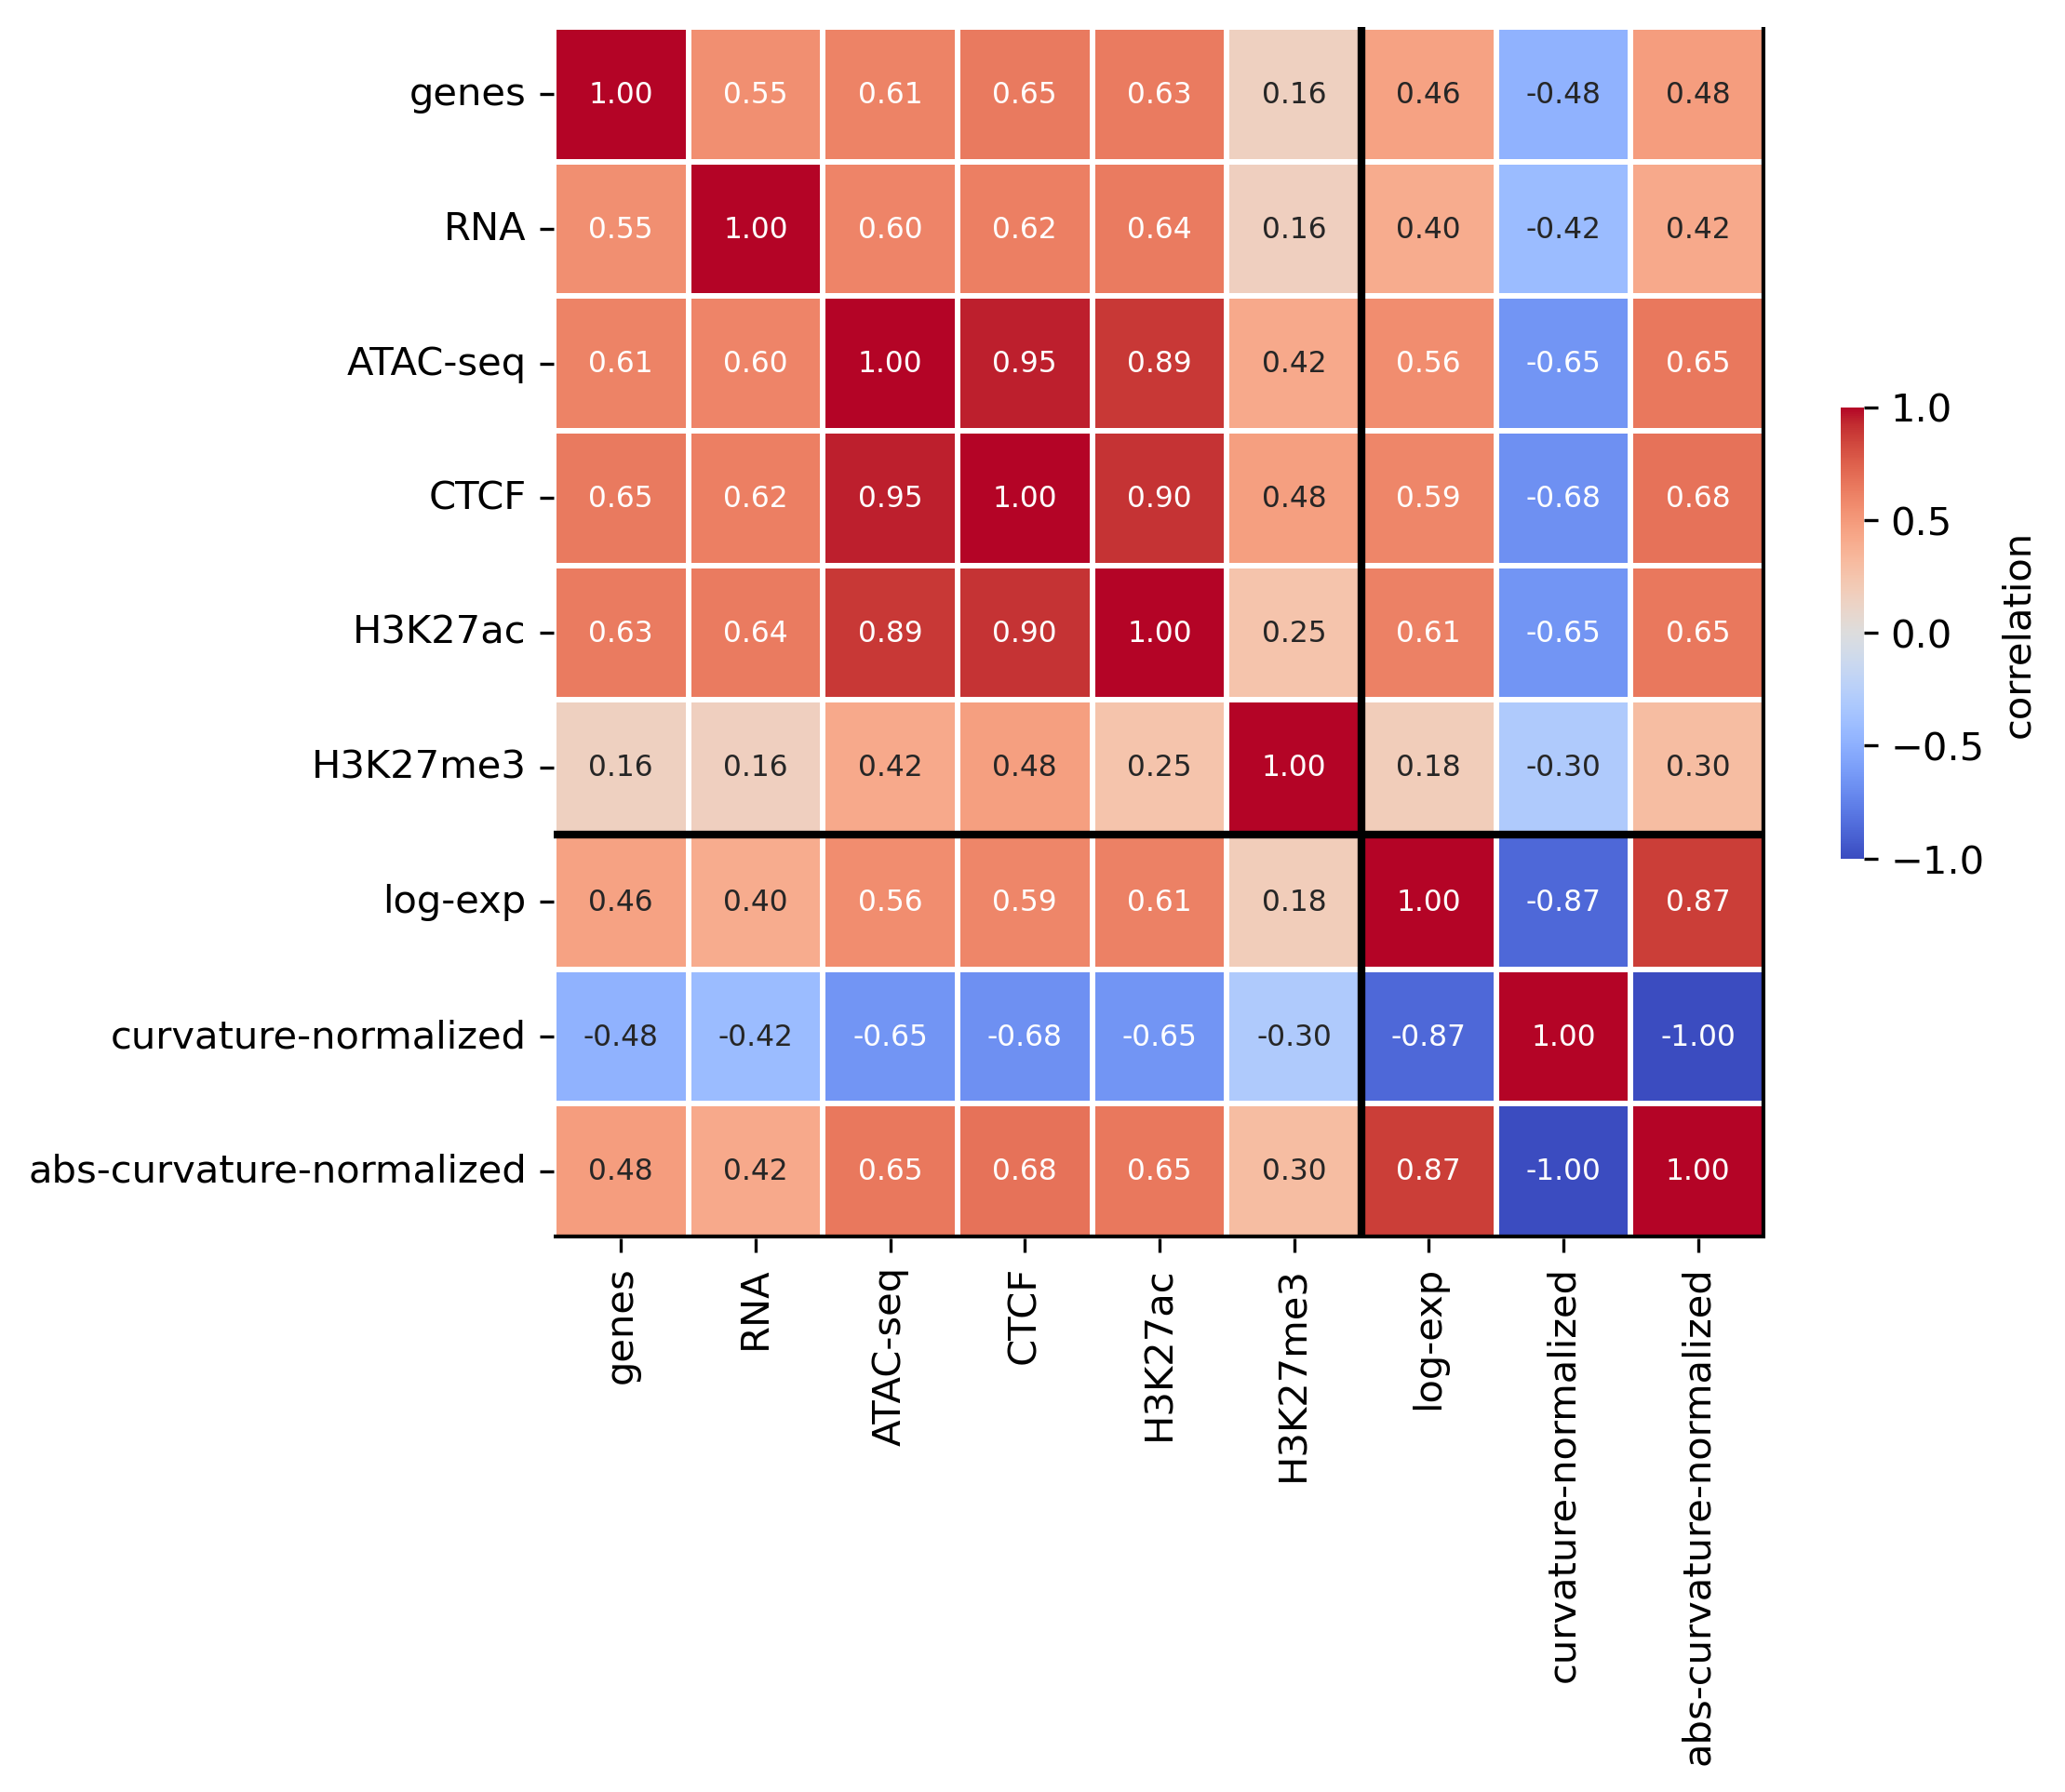

In [128]:
pdf = adata.obs.copy()

column_labels = {
    'n_genes': "genes",
    'RNA_5': "RNA",
    'ATACSeq_3': "ATAC-seq",
    'CTCF': "CTCF",
    'H3K27ac': "H3K27ac",
    'H3K27me3': "H3K27me3",
    'global_hge_logexp_unweighted' : "log-exp",
    'normalized_scalar_curvature'  : "curvature-normalized",
    'abs_normalized_edge_curvature' : "abs-curvature-normalized",
}

corr = pdf[list(column_labels.keys())].corr(method='spearman')
corr.index = list(column_labels.values())
corr.columns = list(column_labels.values())

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7, 7

sns.heatmap(
    corr, 
    square=True,
    linewidths=1,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",  
    annot_kws={"size": 7.5},
    cbar_kws={'shrink': 0.3, 'label' : 'correlation'}
)

# Get the positions of the lines
# These positions are based on the order of your `column_labels`
lines = [6, 9,]

# Add vertical lines
for line in lines:
    plt.axvline(line, color='black', lw=2)
    plt.axhline(line, color='black', lw=2)

plt.show()

In [129]:
CE.head()

,read_index,basename,mean_mapq,median_mapq,n_chromosomes,order,n_bins,read_length_bp,genes,n_genes,edge_curvature,normalized_edge_curvature,abs_normalized_edge_curvature,global_hge_logexp_unweighted,edge_class
read_name,,,,,,,,,,,,,,,
906345b0-7338-4a82-8af1-2b7e1fbebb28,9,batch03,24.750000,19.0,1,4,3,5261,Myo16;Shcbp1,2,-10181.0,-242.404762,242.404762,0.000001,bridge
f35dd078-bf11-441c-a2c1-a830f395ff91,32,batch04,40.333333,60.0,1,3,3,4715,Csmd1,1,-94578.0,-359.612167,359.612167,0.000001,bridge
8edca013-fa78-48e8-889d-f5b5c57186fc,114,batch01,55.571429,60.0,2,7,2,5489,Kcnmb2;Fanci;Pik3ca,3,-6712.0,-2237.333333,2237.333333,0.000001,bridge
b8914f00-8f01-4ae5-acc7-5687db8bd9bd,154,batch01,26.333333,11.0,5,15,5,5622,Dlgap1,1,-6451.0,-1612.750000,1612.750000,0.000001,bridge
713e8f38-278a-4ae6-b53f-48a187476fb1,208,batch04,60.000000,60.0,2,3,2,3554,NaN,0,-6700.0,-1675.000000,1675.000000,0.000001,bridge


In [130]:
cdata = adata.copy()

In [131]:
cdata

AnnData object with n_obs × n_vars = 2335 × 2039865
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII', 'degree_outlier', 'global_hge_logexp_unweighted', 'scalar_curvature', 'normalized_scalar_curvature', 'abs_normalized_edge_curvature'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes', 'edge_curvature', 'normalized_edge_curvature', 'abs_normalized_edge_curvature', 'global_hge_logexp_unweighted'
    uns: 'base_resolution', 'chrom_sizes', 'gdf', 'gene_map', 'intervals'
    layers: 'H'

In [132]:
# #cdata.obs.index = cdata.obs.index.astype(str)
# #CN['bin_name'] = CN['bin_name'].astype(str)

# # 2. Perform a left join to keep all 'obs' records
# cdata.obs = cdata.obs.merge(
#     CN, 
#     how='left', 
#     left_index=True, 
#     right_on='bin_name'
# ).set_index('bin_name')

In [133]:
keep_bins = CN.index.to_list()
keep_reads = CE.index.to_list()

In [134]:
cdata = cdata[cdata.obs_names.isin(keep_bins), :].copy()
cdata = cdata[:, cdata.var_names.isin(keep_reads)].copy()

In [135]:
cdata.obs['global_hge_logexp_unweighted']

bin_name
chr3:34      0.000437
chr6:93      0.000437
chr3:32      0.000437
chr18:3      0.000440
chr12:113    0.000439
               ...   
chr8:17      0.000435
chr8:15      0.000436
chr2:5       0.000436
chr6:32      0.000435
chr8:62      0.000436
Name: global_hge_logexp_unweighted, Length: 195, dtype: float64

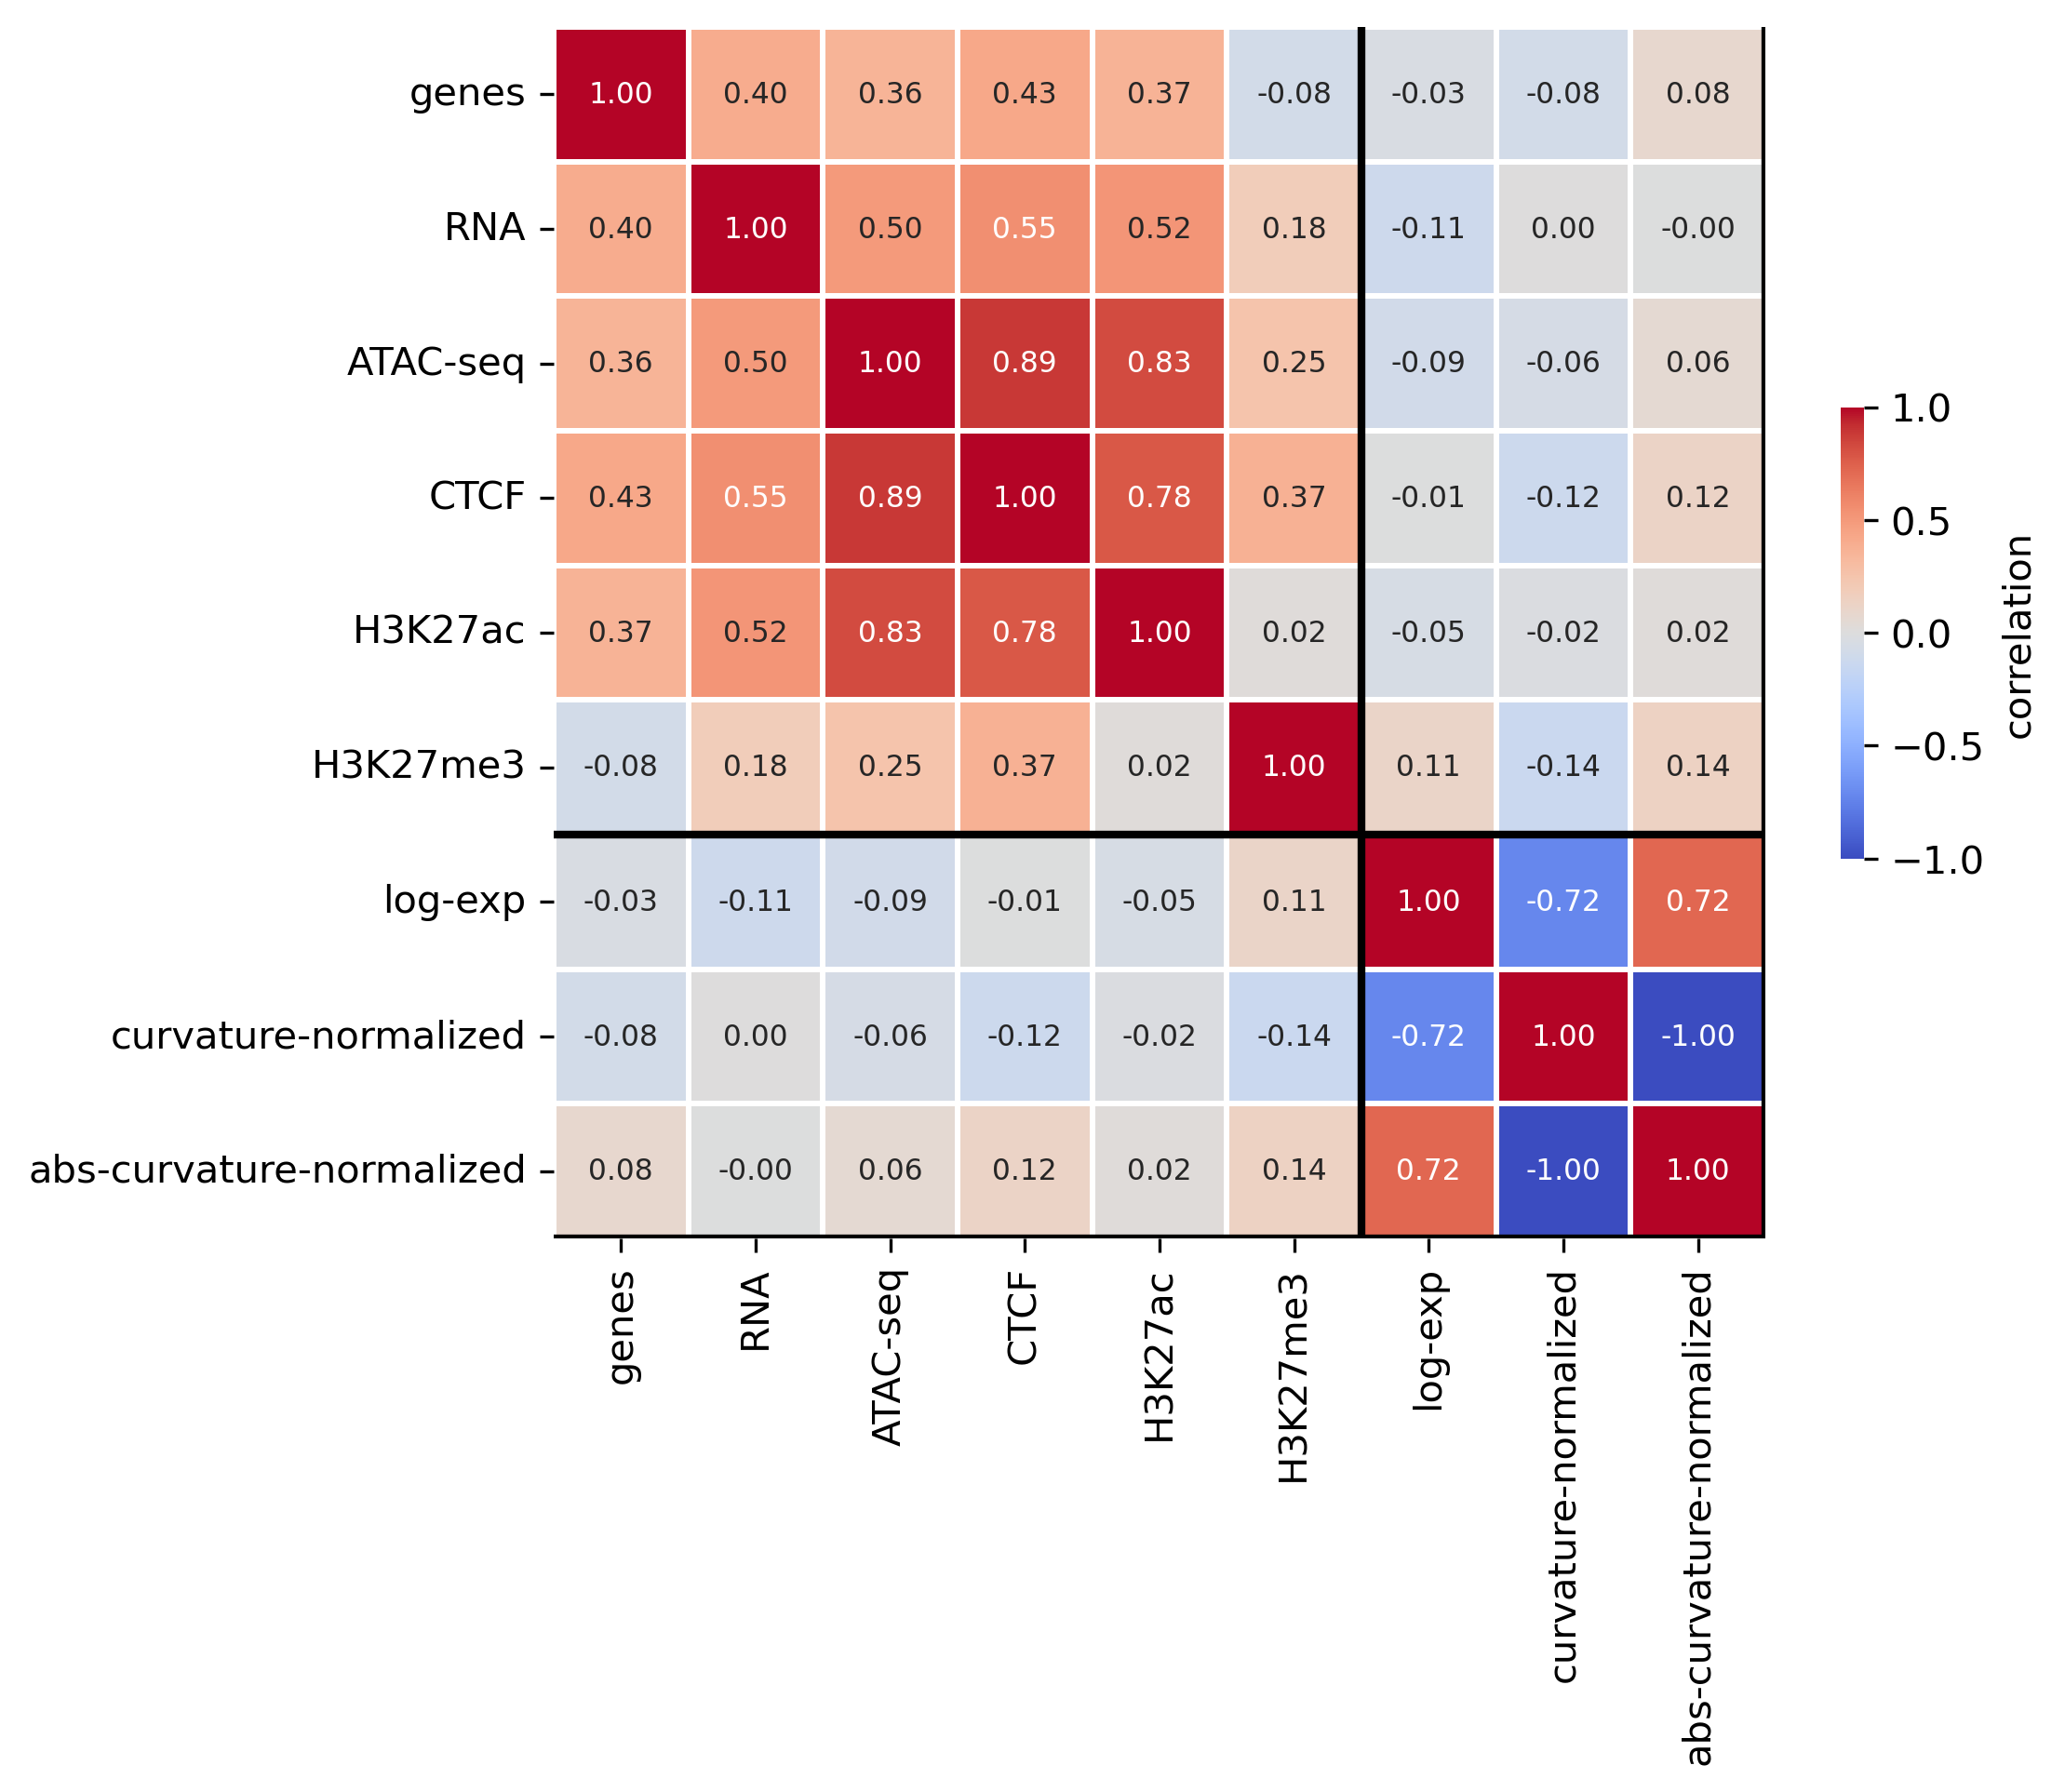

In [136]:
cdf = cdata.obs.copy()

column_labels = {
    'n_genes': "genes",
    'RNA_5': "RNA",
    'ATACSeq_3': "ATAC-seq",
    'CTCF': "CTCF",
    'H3K27ac': "H3K27ac",
    'H3K27me3': "H3K27me3",
    'global_hge_logexp_unweighted' : "log-exp",
    'normalized_scalar_curvature'  : "curvature-normalized",
    'abs_normalized_edge_curvature' : "abs-curvature-normalized",
}

corr = cdf[list(column_labels.keys())].corr(method='spearman')
corr.index = list(column_labels.values())
corr.columns = list(column_labels.values())

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7, 7

sns.heatmap(
    corr, 
    square=True,
    linewidths=1,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",  
    annot_kws={"size": 7.5},
    cbar_kws={'shrink': 0.3, 'label' : 'correlation'}
)

# Get the positions of the lines
# These positions are based on the order of your `column_labels`
lines = [6, 9,]

# Add vertical lines
for line in lines:
    plt.axvline(line, color='black', lw=2)
    plt.axhline(line, color='black', lw=2)

plt.show()

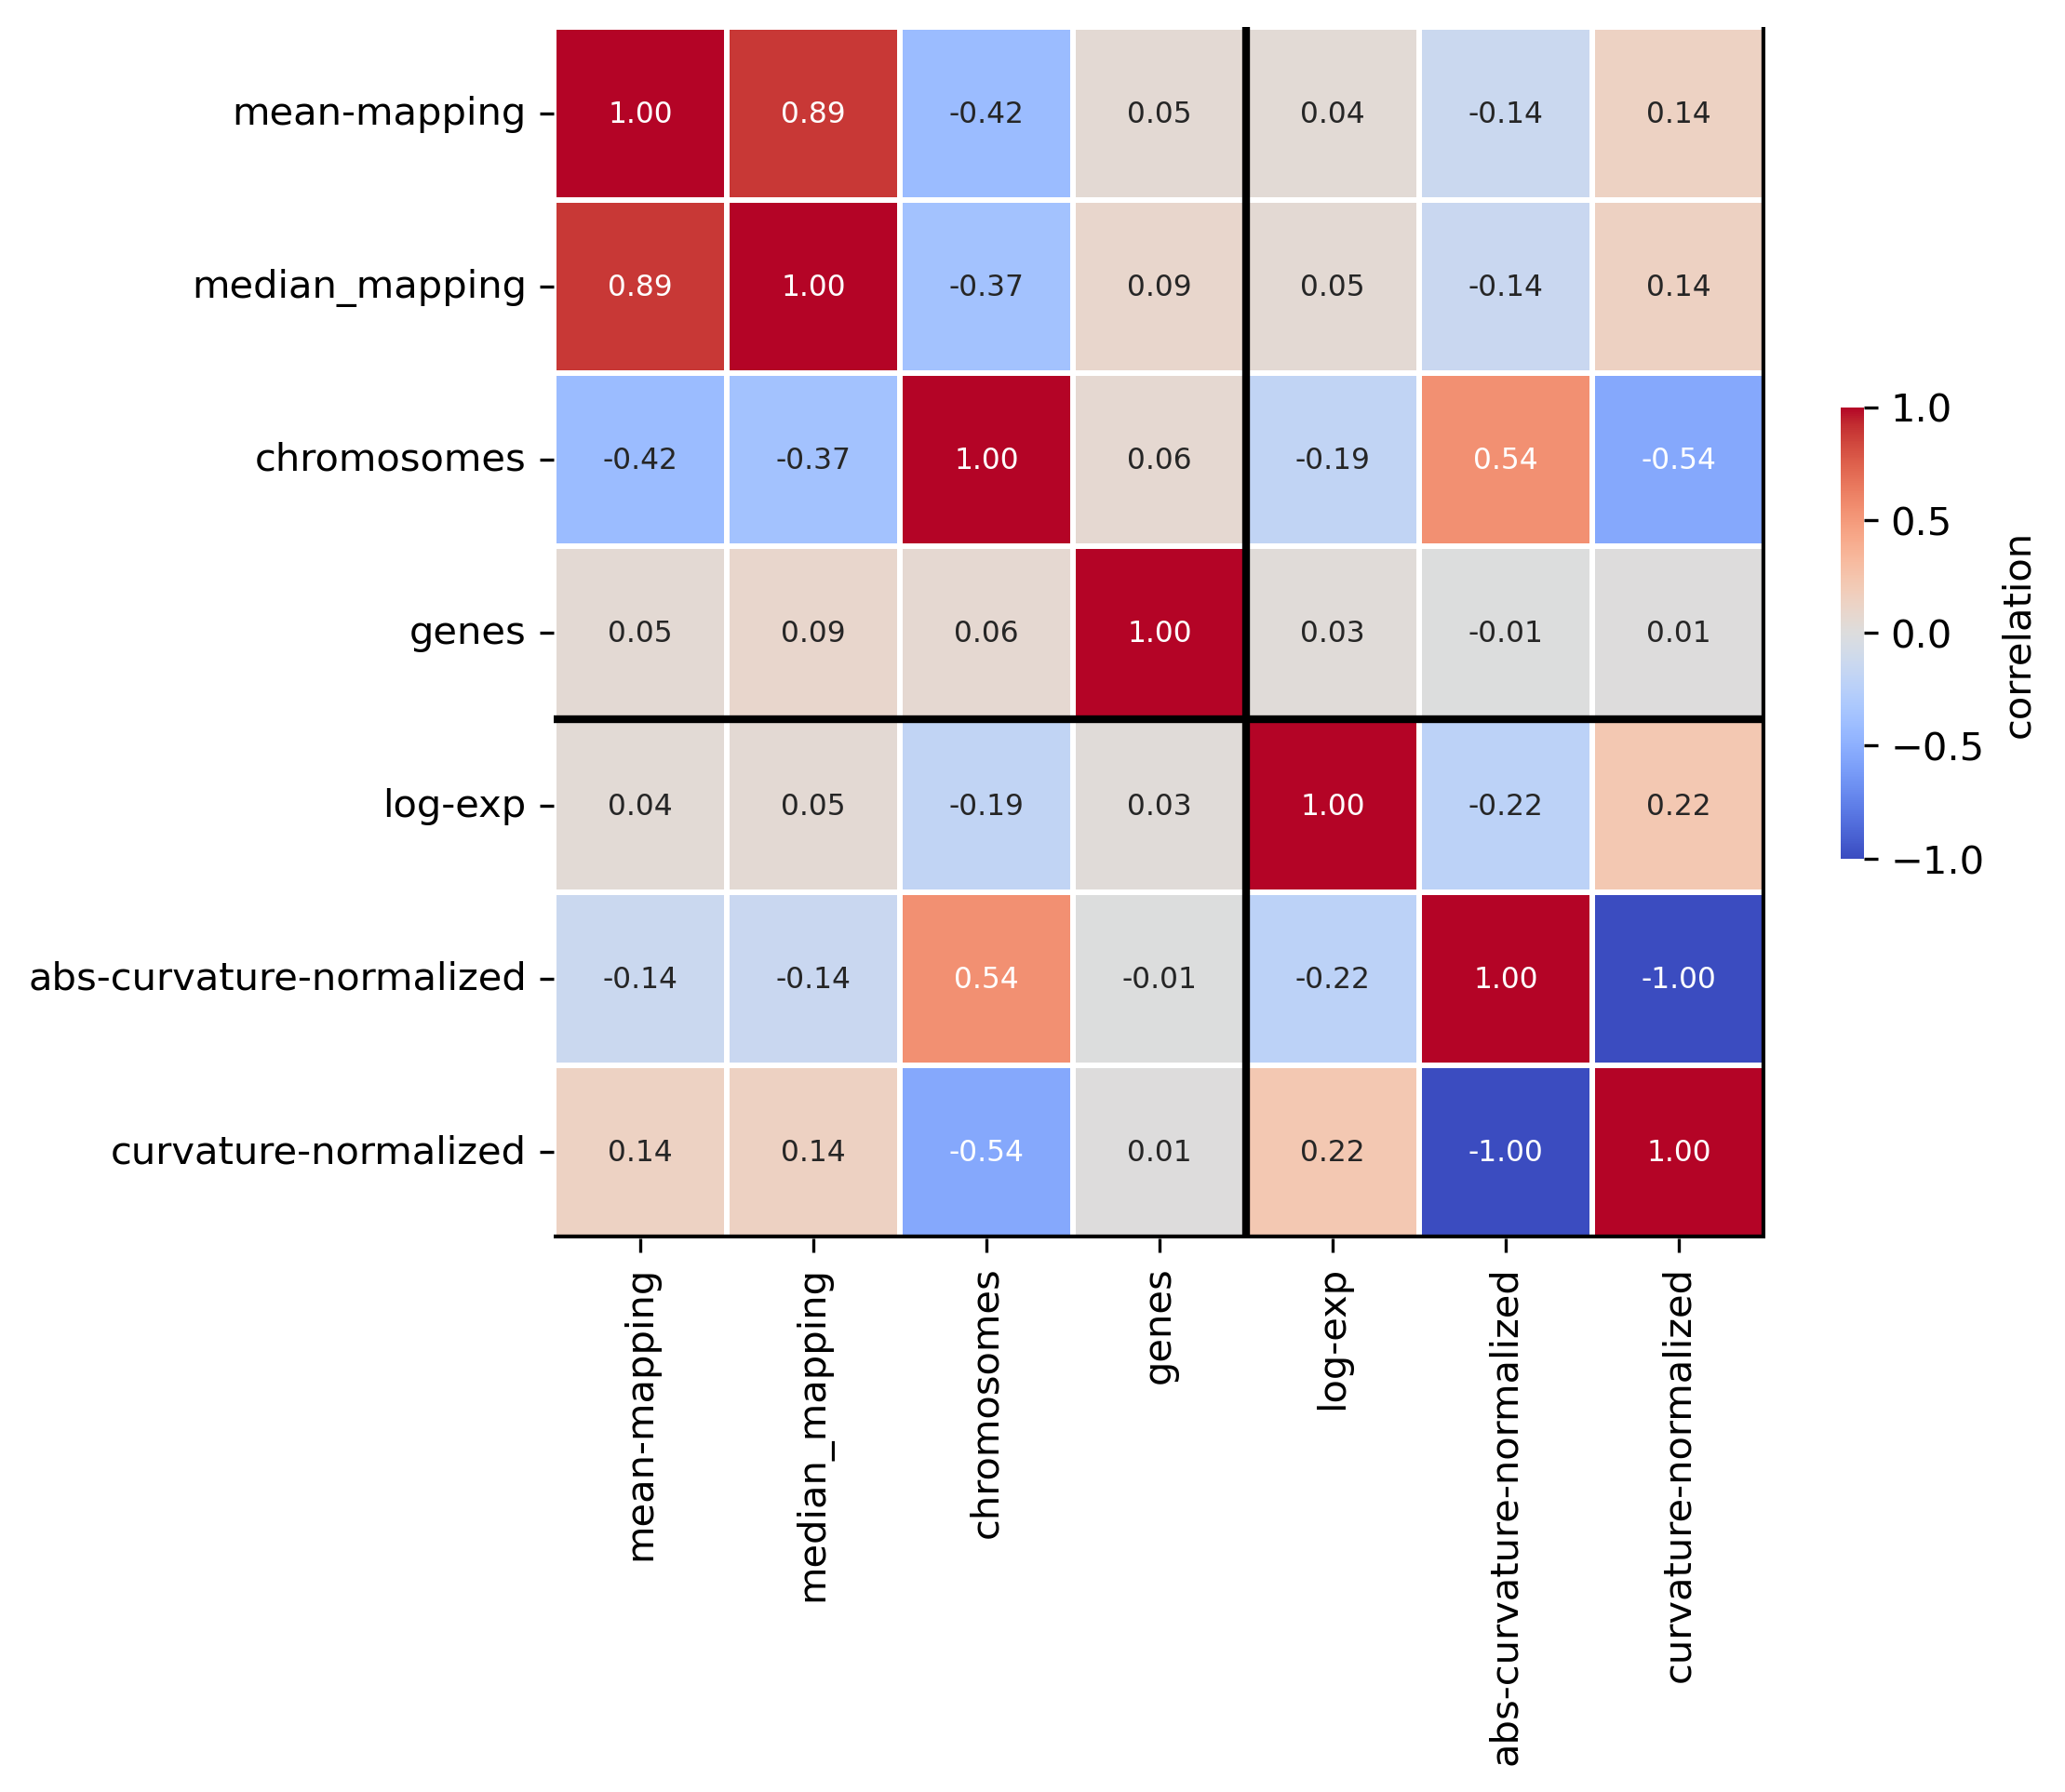

In [137]:
cdf = cdata.var.copy()

column_labels = {
    'mean_mapq': "mean-mapping",
    'median_mapq': "median_mapping",
    'n_chromosomes': "chromosomes",
    'n_genes': "genes",
    'global_hge_logexp_unweighted' : "log-exp",
    'abs_normalized_edge_curvature' : "abs-curvature-normalized",
    'normalized_edge_curvature': "curvature-normalized",
}

corr = cdf[list(column_labels.keys())].corr(method='pearson')
corr.index = list(column_labels.values())
corr.columns = list(column_labels.values())

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7, 7

sns.heatmap(
    corr, 
    square=True,
    linewidths=1,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",  
    annot_kws={"size": 7.5},
    cbar_kws={'shrink': 0.3, 'label' : 'correlation'}
)

# Get the positions of the lines
# These positions are based on the order of your `column_labels`
lines = [4, 7,]

# Add vertical lines
for line in lines:
    plt.axvline(line, color='black', lw=2)
    plt.axhline(line, color='black', lw=2)

plt.show()

In [138]:
target_col = 'abs_normalized_edge_curvature'

# Calculate min and max
col_min = cdata.obs[target_col].min()
col_max = cdata.obs[target_col].max()

# Apply the transformation
cdata.obs[f'{target_col}_norm'] = (cdata.obs[target_col] - col_min) / (col_max - col_min)

In [139]:
cdata

AnnData object with n_obs × n_vars = 195 × 83144
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII', 'degree_outlier', 'global_hge_logexp_unweighted', 'scalar_curvature', 'normalized_scalar_curvature', 'abs_normalized_edge_curvature', 'abs_normalized_edge_curvature_norm'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes', 'edge_curvature', 'normalized_edge_curvature', 'abs_normalized_edge_curvature', 'global_hge_logexp_unweighted'
    uns: 'base_resolution', 'chrom_sizes', 'gdf', 'gene_map', 'intervals'
    layers: 'H'

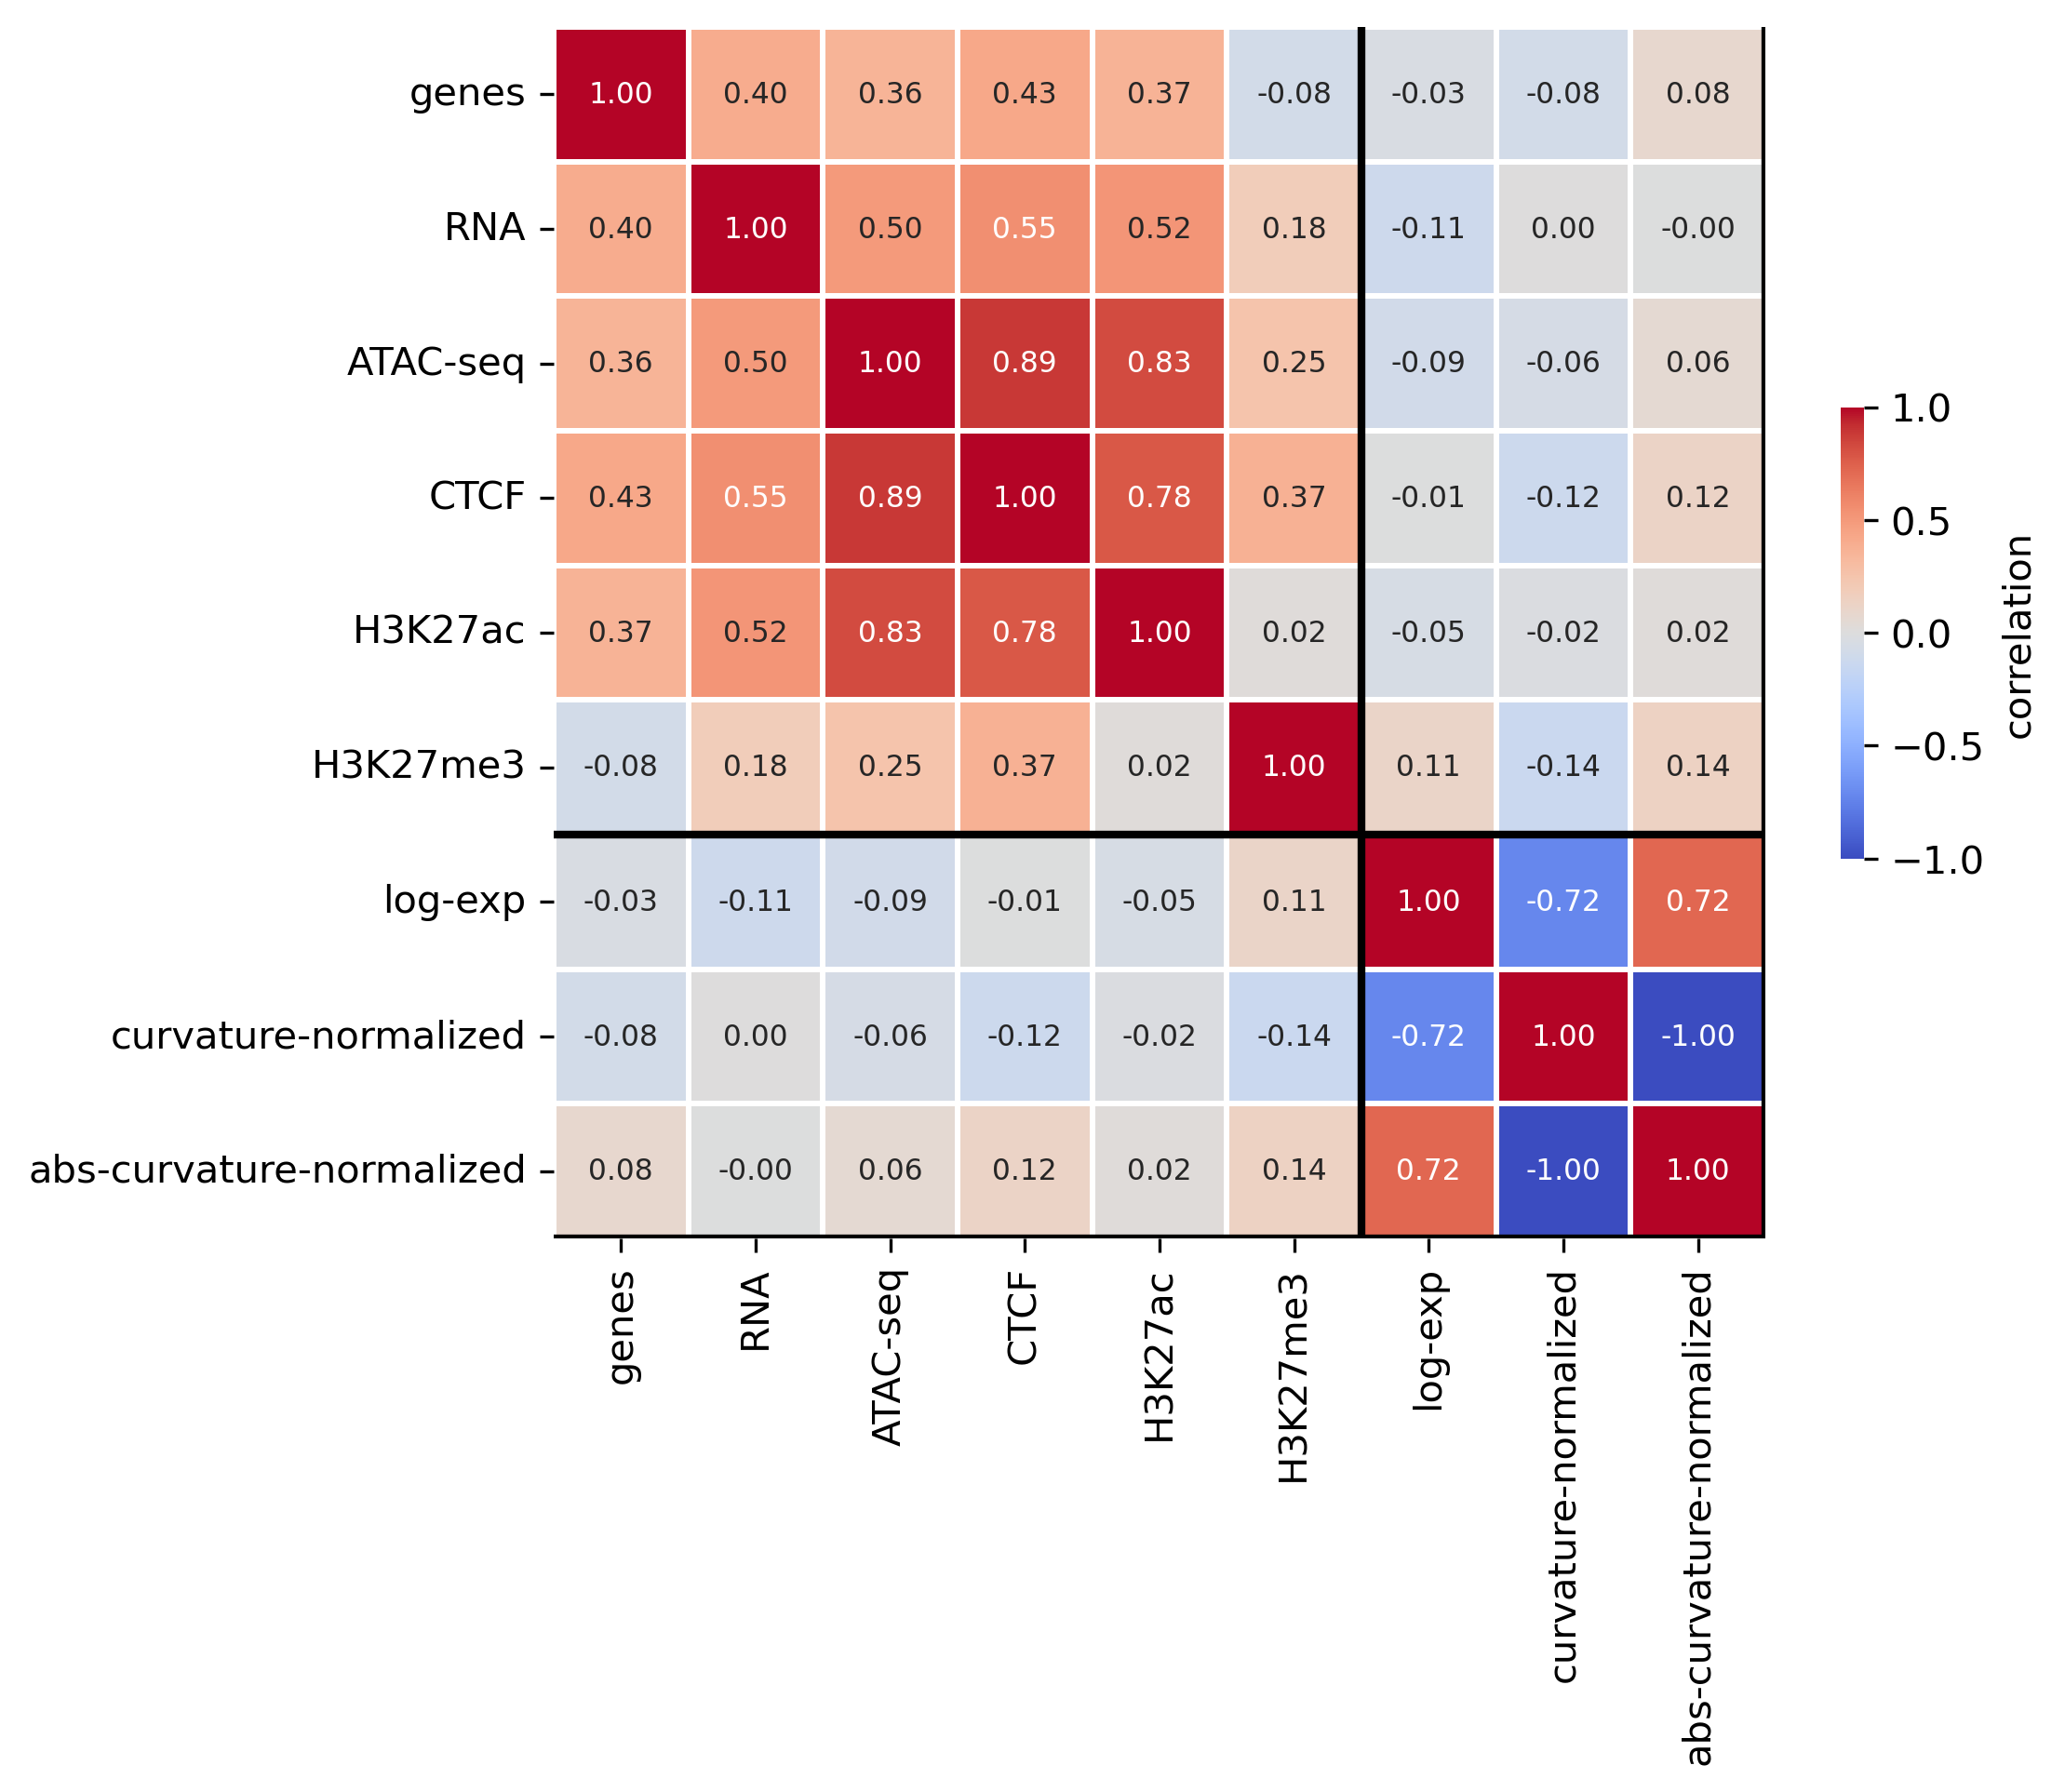

In [140]:
cdf = cdata.obs.copy()

column_labels = {
    'n_genes': "genes",
    'RNA_5': "RNA",
    'ATACSeq_3': "ATAC-seq",
    'CTCF': "CTCF",
    'H3K27ac': "H3K27ac",
    'H3K27me3': "H3K27me3",
    'global_hge_logexp_unweighted' : "log-exp",
    'normalized_scalar_curvature'  : "curvature-normalized",
    'abs_normalized_edge_curvature' : "abs-curvature-normalized",
}

corr = cdf[list(column_labels.keys())].corr(method='spearman')
corr.index = list(column_labels.values())
corr.columns = list(column_labels.values())

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7, 7

sns.heatmap(
    corr, 
    square=True,
    linewidths=1,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",  
    annot_kws={"size": 7.5},
    cbar_kws={'shrink': 0.3, 'label' : 'correlation'}
)

# Get the positions of the lines
# These positions are based on the order of your `column_labels`
lines = [6, 9,]

# Add vertical lines
for line in lines:
    plt.axvline(line, color='black', lw=2)
    plt.axhline(line, color='black', lw=2)

plt.show()

In [141]:
keep_reads = CE.index.to_list()

edata = adata.copy()

edata = edata[:, edata.var_names.isin(keep_reads)].copy()

In [142]:
var_df = edata.var.copy()
var_df["is_inter"] = var_df["n_chromosomes"] > 1
var_df["n_nodes"]  = var_df["n_bins"]          # same concept as core's n_nodes

sc_n_inter = var_df["is_inter"].sum()
sc_n_intra = (~var_df["is_inter"]).sum()



In [143]:
locus_chroms = edata.obs["chrom"].values
all_chroms_sc = sorted(
    edata.obs["chrom"].unique(),
    key=lambda x: int(x.replace("chr","")) if x.replace("chr","").isdigit() else 100
)
n_chr = len(all_chroms_sc)
chrom_idx = {c: i for i, c in enumerate(all_chroms_sc)}

# Build (n_chroms × n_loci) indicator matrix
C = np.zeros((n_chr, edata.n_obs), dtype=np.float32)
for c, i in chrom_idx.items():
    C[i, locus_chroms == c] = 1.0
C_sp = sp.csr_matrix(C)

H = edata.X.tocsc().astype(np.float32)          # (n_loci × n_reads)

# chrom_presence[i, j] = 1 iff chrom i has ≥1 locus in read j
chrom_presence = (C_sp @ H).toarray() > 0

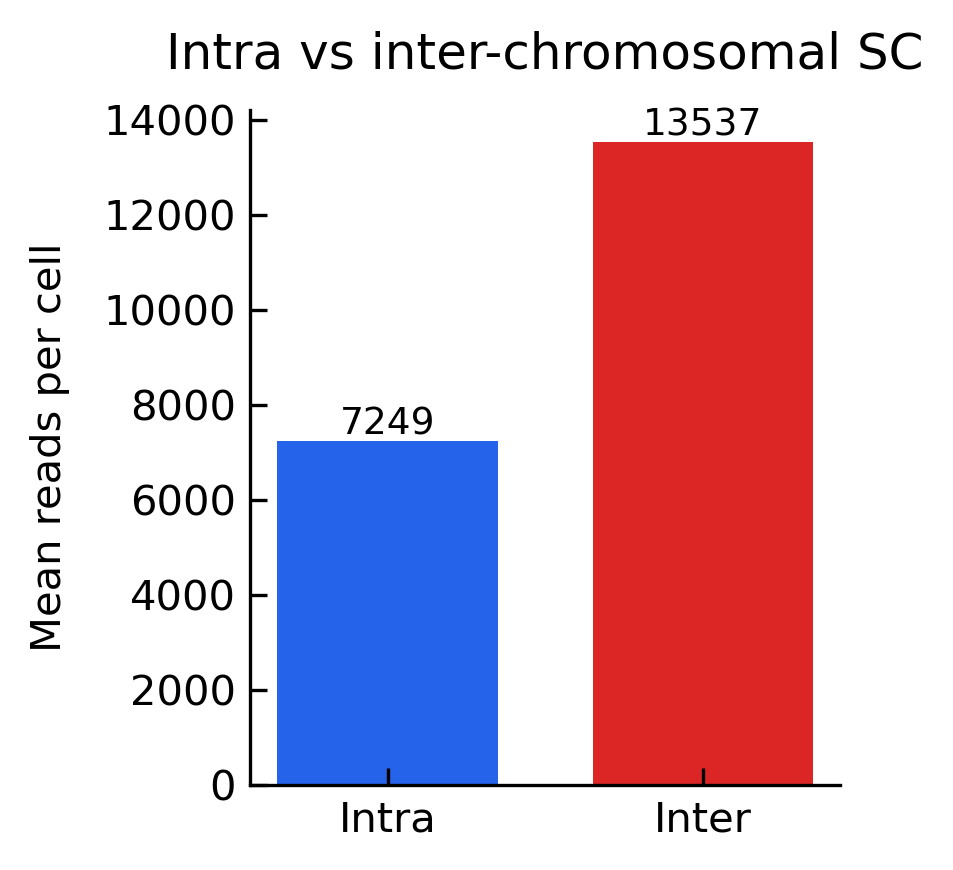

In [144]:
per_cell = (
    var_df.groupby("basename")["is_inter"]
    .agg(n_inter="sum", n_total="count")
    .assign(n_intra=lambda d: d["n_total"] - d["n_inter"])
)
mean_intra = per_cell["n_intra"].mean()
mean_inter = per_cell["n_inter"].mean()

fig, ax = plt.subplots(figsize=(3, 3))
counts = [mean_intra, mean_inter]
labels = ["Intra", "Inter"]
colors = ["#2563eb", "#dc2626"]
ax.bar(labels, counts, color=colors, edgecolor="none", width=0.7)
ax.set_ylabel("Mean reads per cell", labelpad=8)
ax.set_title("Intra vs inter-chromosomal SC", pad=10, loc="center")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(direction="in", length=4, width=0.8)
for i, v in enumerate(counts):
    ax.text(i, v + max(counts)*0.01, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

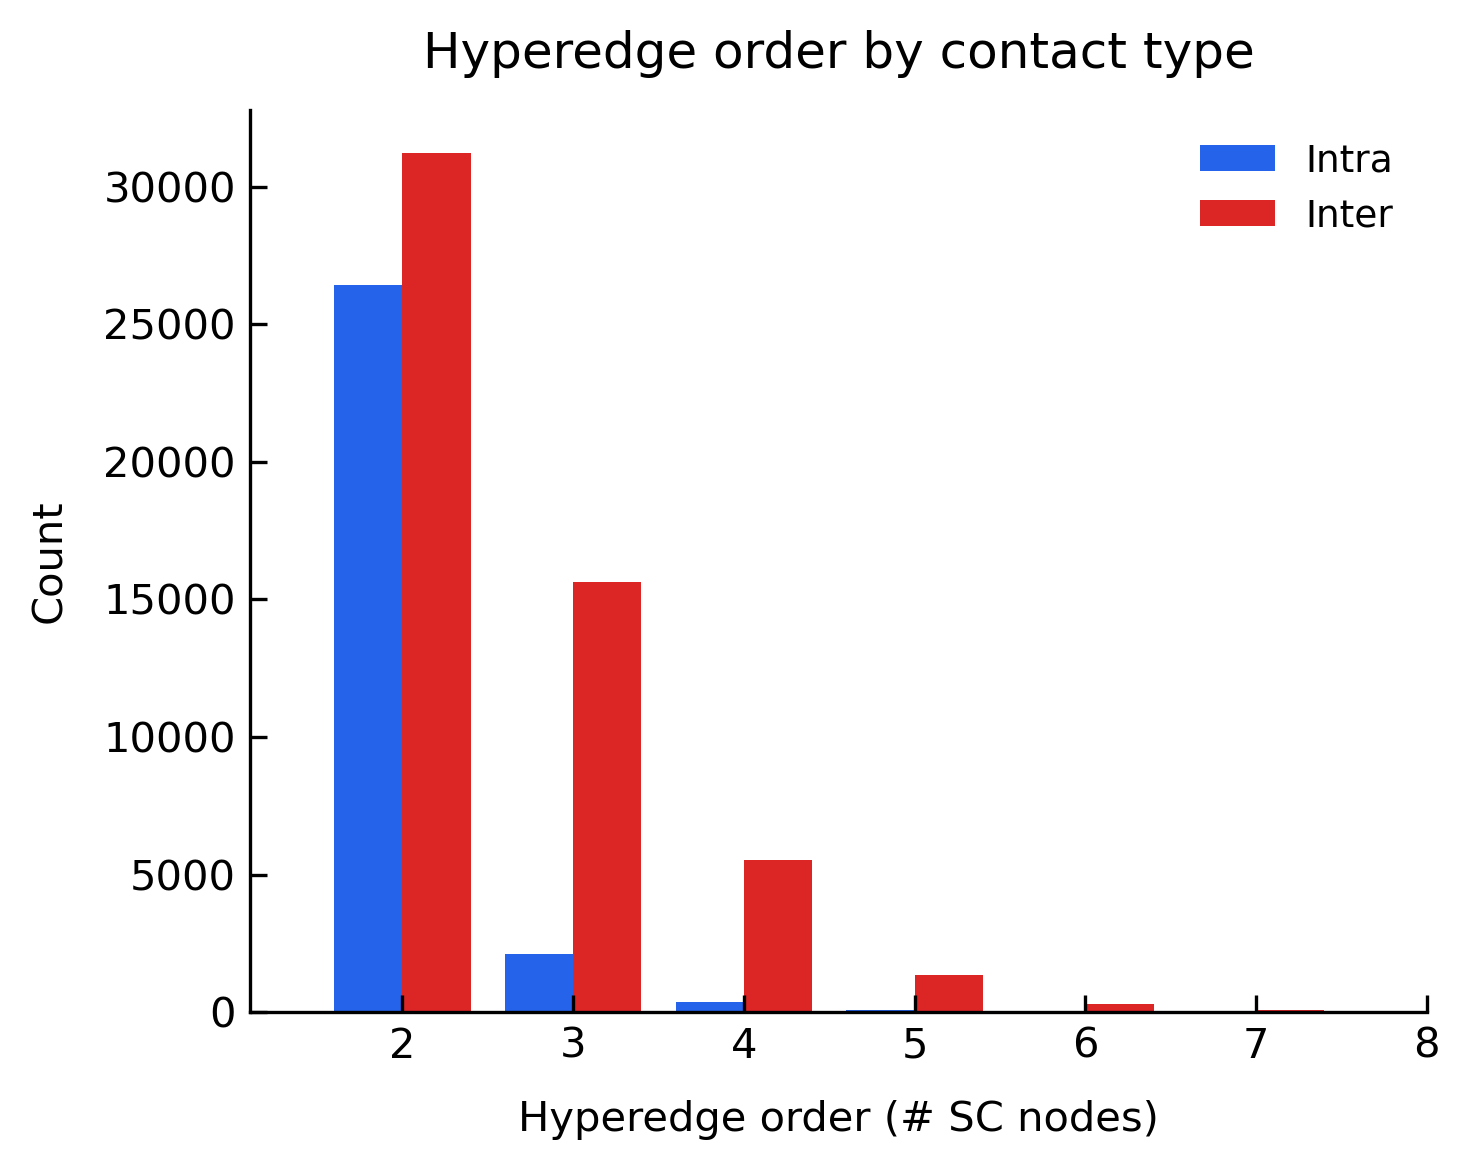

In [145]:
fig, ax = plt.subplots(figsize=(5, 4))
bins  = np.arange(2, 12)
intra = var_df[~var_df["is_inter"]]["n_nodes"].values
inter = var_df[ var_df["is_inter"]]["n_nodes"].values
width = 0.4
intra_counts = np.array([(intra == b).sum() for b in bins])
inter_counts = np.array([(inter == b).sum() for b in bins])
ax.bar(bins - width/2, intra_counts, width=width, color="#2563eb", label="Intra", edgecolor="none")
ax.bar(bins + width/2, inter_counts, width=width, color="#dc2626", label="Inter", edgecolor="none")
ax.set_xlabel("Hyperedge order (# SC nodes)", labelpad=8)
ax.set_ylabel("Count", labelpad=8)
ax.set_title("Hyperedge order by contact type", pad=10, loc="center")
ax.set_xlim(right=8)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(direction="in", length=4, width=0.8)
plt.tight_layout()
plt.show()

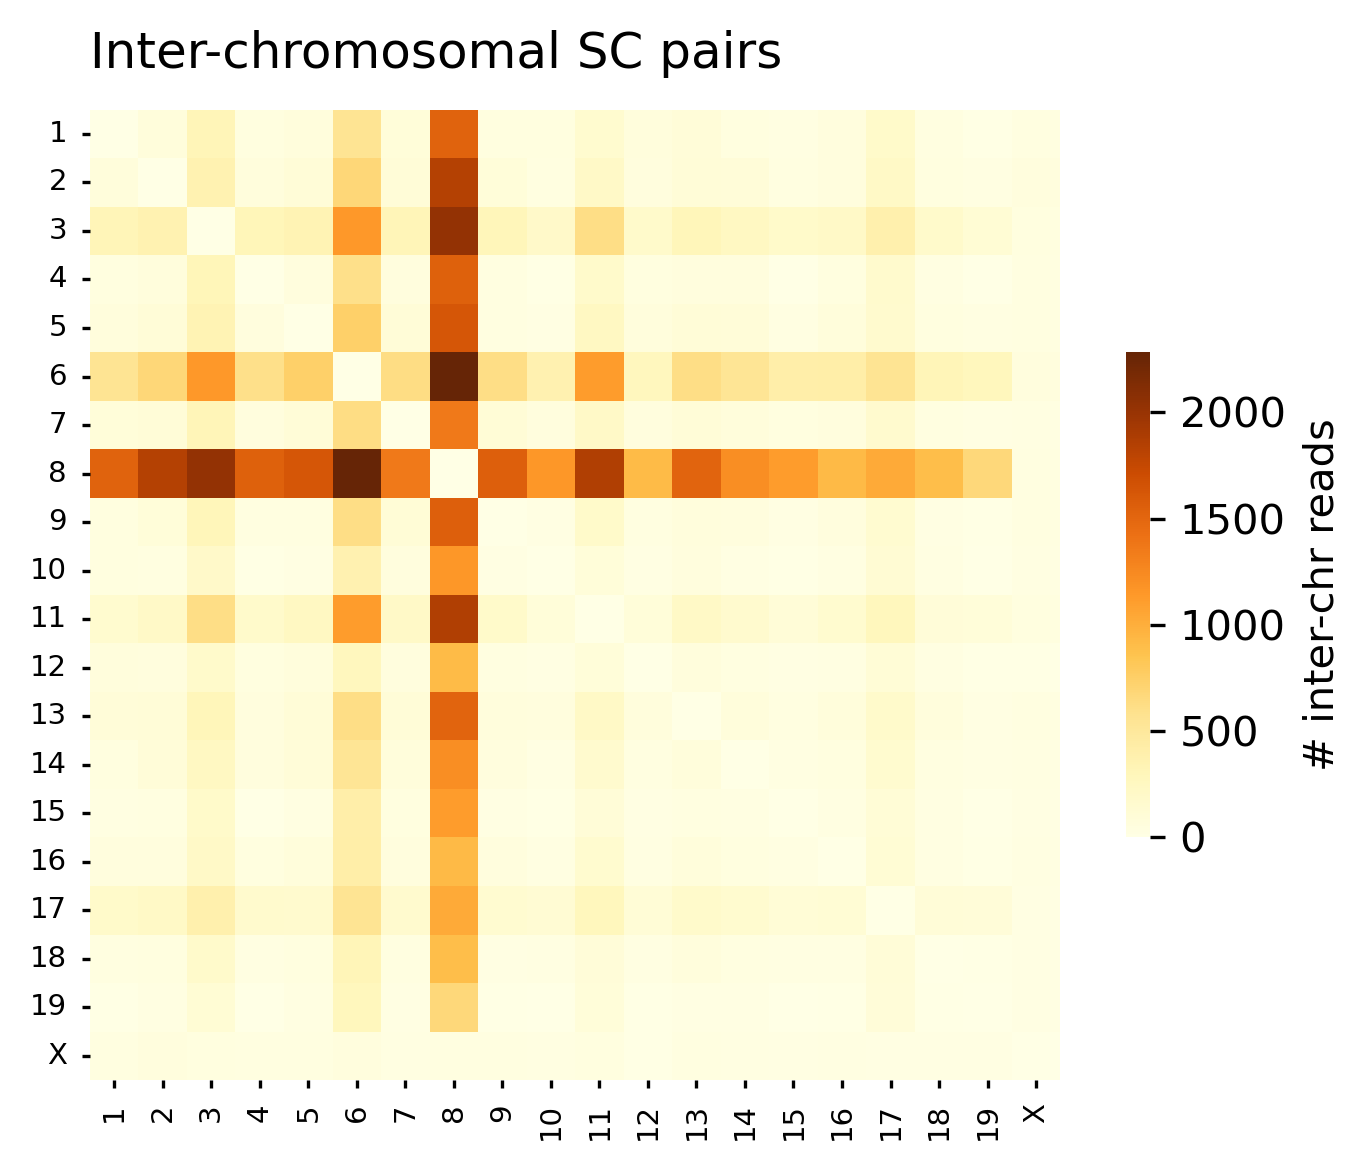

In [146]:
inter_read_mask = var_df["is_inter"].values                  # bool (n_reads,)
inter_presence  = chrom_presence[:, inter_read_mask]         # (n_chroms × n_inter_reads)

# For each pair (i,j), count reads where both chroms are present
mat_sc = np.zeros((n_chr, n_chr))
for i in range(n_chr):
    for j in range(i+1, n_chr):
        cnt = int((inter_presence[i] & inter_presence[j]).sum())
        mat_sc[i, j] = cnt
        mat_sc[j, i] = cnt

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    mat_sc,
    cmap="YlOrBr",
    square=True,
    xticklabels=all_chroms_sc,
    yticklabels=all_chroms_sc,
    linewidths=0,
    cbar_kws={"shrink": 0.5, "label": "# inter-chr reads"},
    ax=ax,
)
ax.set_title("Inter-chromosomal SC pairs", pad=10, loc="left")
ax.tick_params(labelsize=7, length=2)
plt.tight_layout()
plt.show()